In [1]:
import pathlib
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pytensor.scan import scan
# ignore threadpoolctl warnings from pymc
import warnings
warnings.filterwarnings('ignore', module="threadpoolctl")

c:\Users\erik.hostens\AppData\Local\miniforge3\envs\Flambay\Lib\site-packages\arviz\__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
train_folder = pathlib.Path("..") / "assets" / "CBM_dataset" / "train"

train_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in train_folder.glob("*.csv")
}

list(train_dataframes.keys())

['complete_df_train']

In [3]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
for name, df in train_dataframes.items():
	print(f"{name}:")
	print(df.head())
	print("-" * 120)

complete_df_train:
   machine_id  time  degra_level_observed  region  route      speed      load  brake_temperature  vibration_level  rul  segment_id
0           1     0              0.000000       1      1  33.752256  0.718434           0.000000         0.047835   88           1
1           1     1              0.042079       1      0  90.884743  0.637161           3.031550         0.000000   87           1
2           1     2              0.000000       1      1  29.915994  0.539073           0.000000         0.142555   86           1
3           1     3              0.000000       1      1  33.888960  0.630980           0.000000         0.000000   85           1
4           1     4              0.000000       1      1  32.337547  0.538448           7.716752         0.059371   84           1
------------------------------------------------------------------------------------------------------------------------


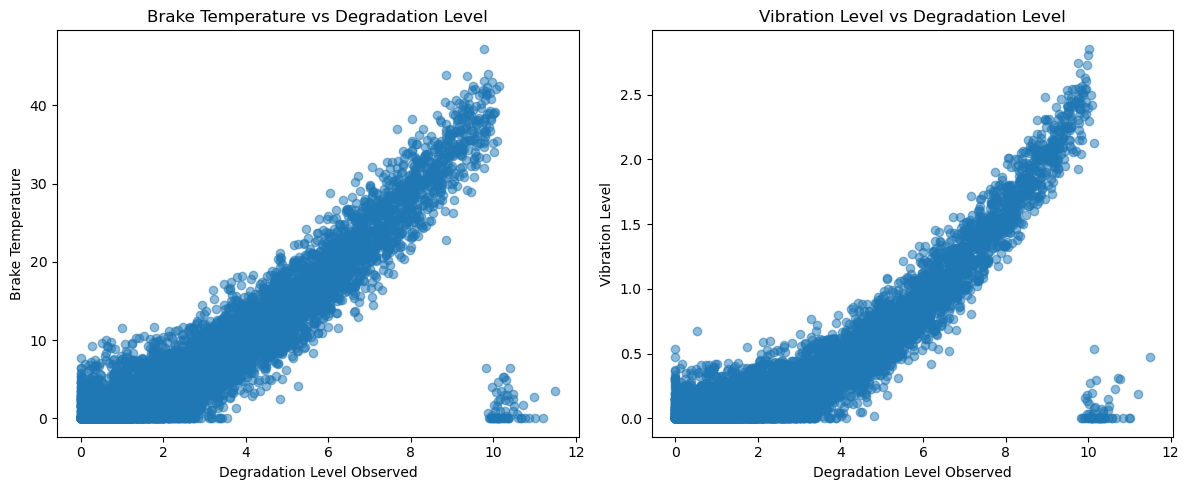

In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['degra_level_observed'], df['brake_temperature'], alpha=0.5)
plt.xlabel('Degradation Level Observed')
plt.ylabel('Brake Temperature')
plt.title('Brake Temperature vs Degradation Level')

plt.subplot(1, 2, 2)
plt.scatter(df['degra_level_observed'], df['vibration_level'], alpha=0.5)
plt.xlabel('Degradation Level Observed')
plt.ylabel('Vibration Level')
plt.title('Vibration Level vs Degradation Level')

plt.tight_layout()
plt.show()

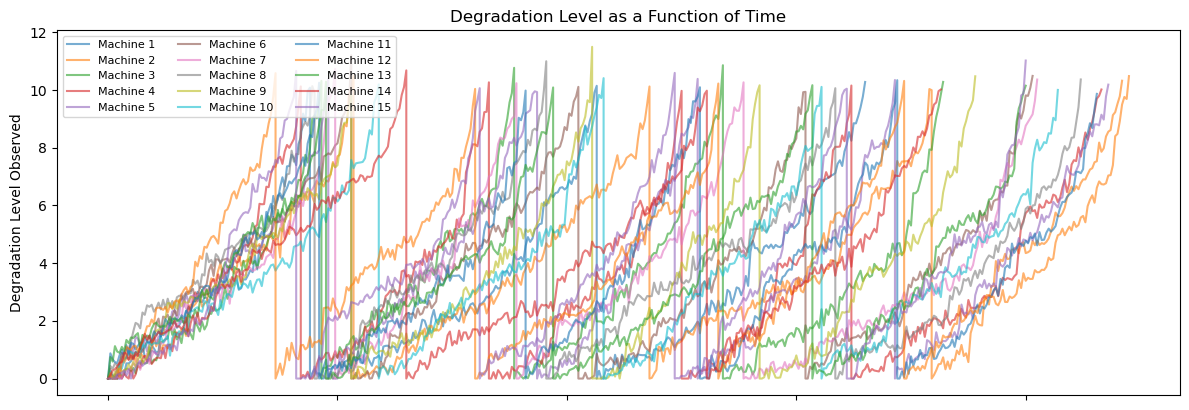

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for machine_id, group in df.groupby('machine_id'):
    axes[0].plot(group['time'], group['degra_level_observed'], alpha=0.6, label=f'Machine {machine_id}')
    axes[1].plot(group['time'], group['rul'], alpha=0.6, label=f'Machine {machine_id}')

axes[0].set_ylabel('Degradation Level Observed')
axes[0].set_title('Degradation Level as a Function of Time')
axes[0].legend(loc='upper left', fontsize=8, ncol=3)
axes[1].set_visible(False)

axes[1].set_ylabel('RUL (Remaining Useful Life)')
axes[1].set_title('RUL as a Function of Time')
axes[1].set_xlabel('Time')
axes[1].legend(loc='upper right', fontsize=8, ncol=3)

plt.tight_layout()
plt.show()

In [6]:
# Build reset-aware time variable time_reset: reset to 0 for every new segment_id
df["time_reset"] = df["time"] - df.groupby("segment_id")["time"].transform("min")
df[["machine_id", "time", "rul", "segment_id", "time_reset"]].head()

,machine_id,time,rul,segment_id,time_reset
0,1,0,88,1,0
1,1,1,87,1,1
2,1,2,86,1,2
3,1,3,85,1,3
4,1,4,84,1,4


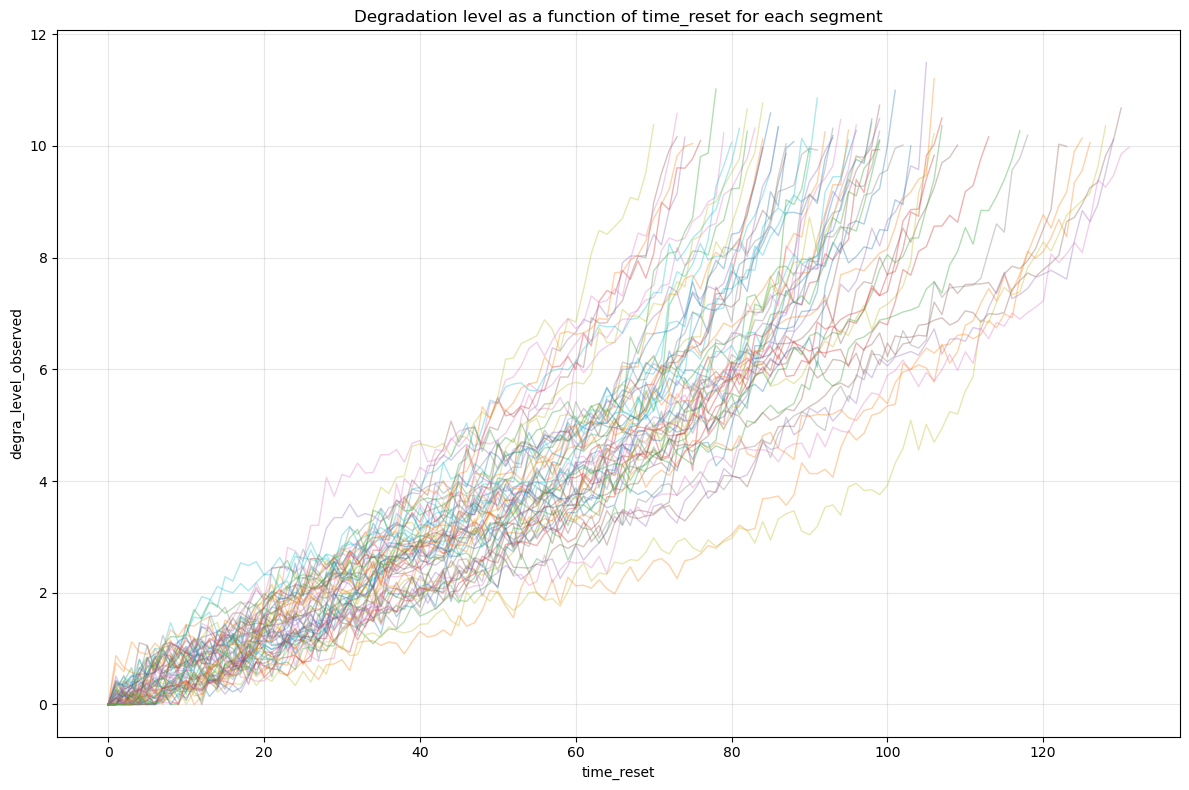

In [7]:
plt.figure(figsize=(12, 8))

for segment_id, group in df.groupby("segment_id"):
    group = group.sort_values("time_reset")
    plt.plot(
        group["time_reset"],
        group["degra_level_observed"],
        alpha=0.35,
        linewidth=1.0,
    )

plt.xlabel("time_reset")
plt.ylabel("degra_level_observed")
plt.title("Degradation level as a function of time_reset for each segment")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

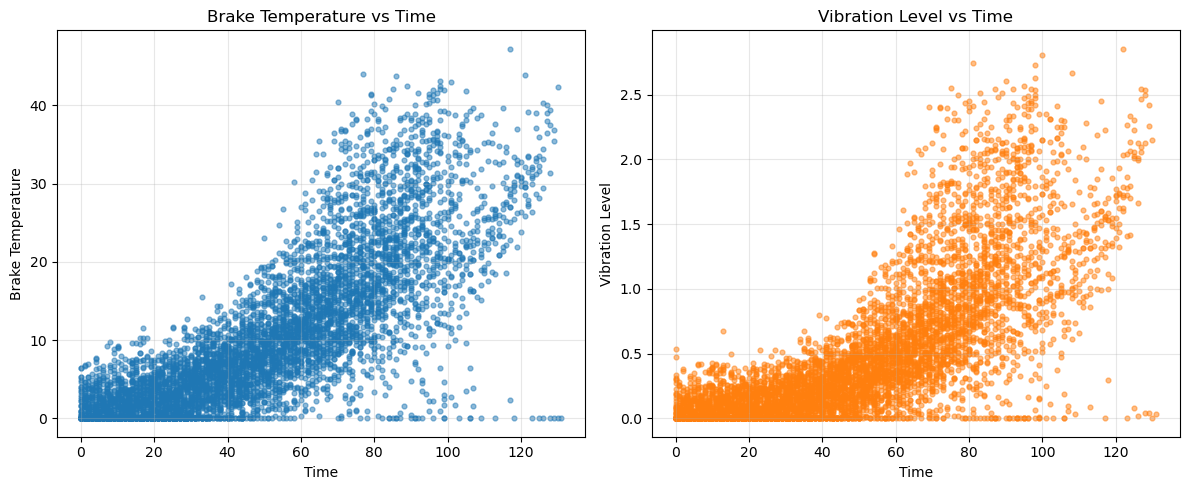

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df["time_reset"], df["brake_temperature"], alpha=0.5, s=12)
plt.xlabel("Time")
plt.ylabel("Brake Temperature")
plt.title("Brake Temperature vs Time")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(df["time_reset"], df["vibration_level"], alpha=0.5, s=12, color="tab:orange")
plt.xlabel("Time")
plt.ylabel("Vibration Level")
plt.title("Vibration Level vs Time")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Segments with RUL=0 records: 63


,segment_id,machine_id,time,brake_temperature,vibration_level
0,1,1,87,38.087585,2.546686
1,2,1,212,38.977143,2.335471
2,3,1,329,34.726784,1.923296
3,5,2,106,34.003056,2.294985
4,6,2,235,39.436713,2.494246
...,...,...,...,...,...
58,73,15,81,38.046485,2.740316
59,74,15,161,41.382140,2.431409
60,75,15,246,40.846860,2.439246
61,76,15,321,38.909980,2.396944


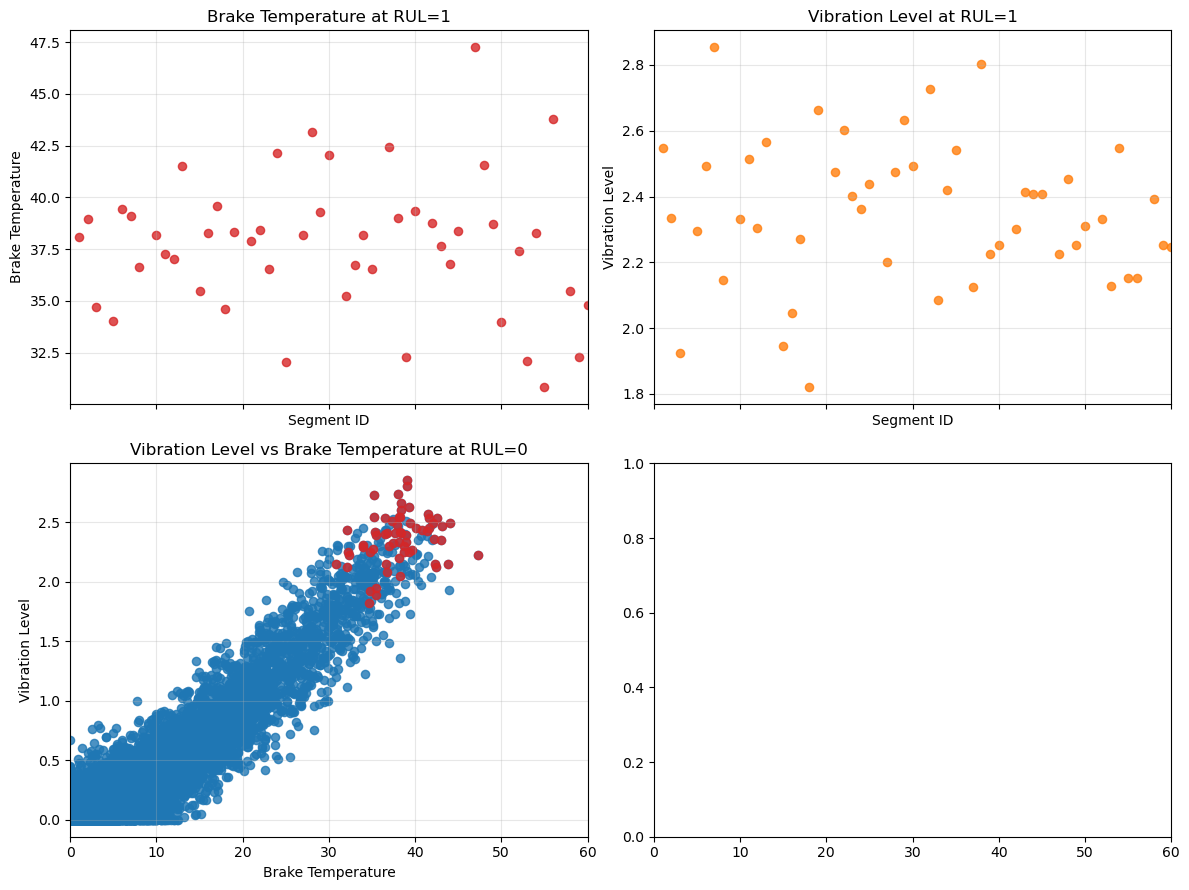

In [9]:
# Brake temperature and vibration level at failure point (RUL = 0) for all segments
eol_df = (
    df.loc[df["rul"] == 1, ["segment_id", "machine_id", "time", "brake_temperature", "vibration_level"]]
      .sort_values(["segment_id", "time"])
      .groupby("segment_id", as_index=False)
      .last()
)

print(f"Segments with RUL=0 records: {len(eol_df)}")
display(eol_df[["segment_id", "machine_id", "time", "brake_temperature", "vibration_level"]])

fig, ax = plt.subplots(2, 2, figsize=(12, 9), sharex=True)

ax[0, 0].scatter(eol_df["segment_id"], eol_df["brake_temperature"], alpha=0.8, s=35, color="tab:red")
ax[0, 0].set_title("Brake Temperature at RUL=1")
ax[0, 0].set_xlabel("Segment ID")
ax[0, 0].set_ylabel("Brake Temperature")
ax[0, 0].grid(alpha=0.3)

ax[0, 1].scatter(eol_df["segment_id"], eol_df["vibration_level"], alpha=0.8, s=35, color="tab:orange")
ax[0, 1].set_title("Vibration Level at RUL=1")
ax[0, 1].set_xlabel("Segment ID")
ax[0, 1].set_ylabel("Vibration Level")
ax[0, 1].grid(alpha=0.3)

ax[1, 0].scatter(df["brake_temperature"], df["vibration_level"], alpha=0.8, s=35, color="tab:blue")
ax[1, 0].scatter(eol_df["brake_temperature"], eol_df["vibration_level"], alpha=0.8, s=35, color="tab:red")
ax[1, 0].set_title("Vibration Level vs Brake Temperature at RUL=0")
ax[1, 0].set_xlabel("Brake Temperature")
ax[1, 0].set_ylabel("Vibration Level")
ax[1, 0].set_xlim(0,60)
ax[1, 0].grid(alpha=0.3)

plt.tight_layout()
plt.show()

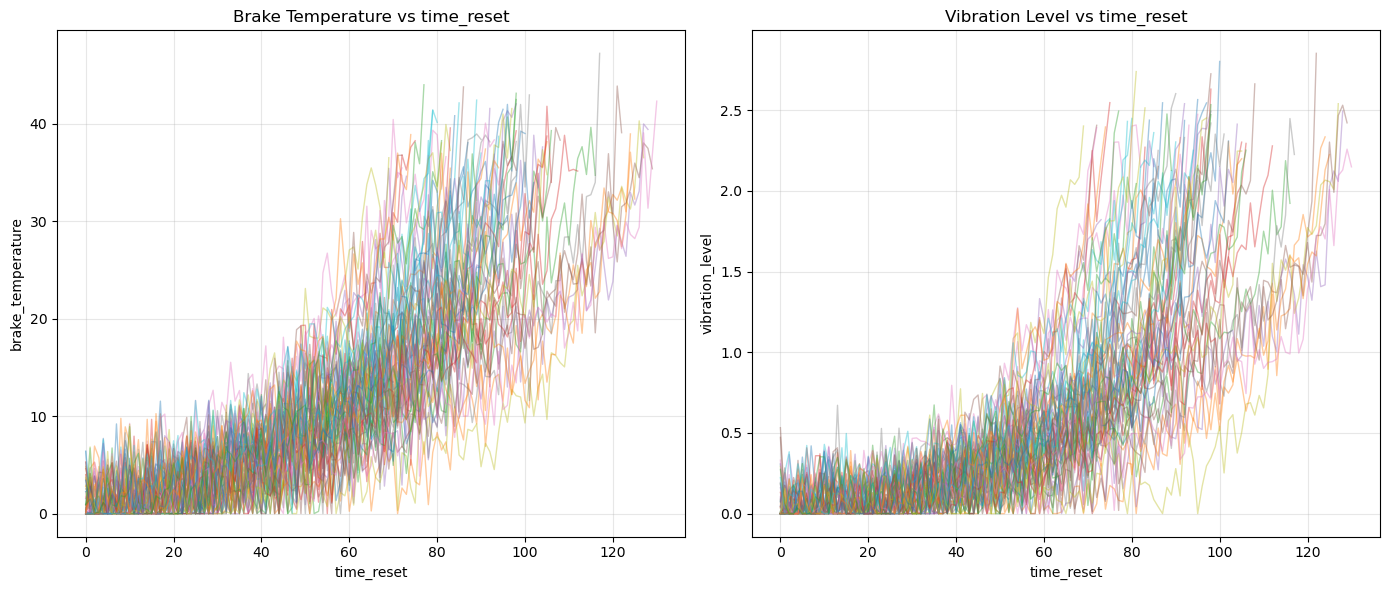

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for segment_id, group in df.groupby("segment_id"):
    group = group.sort_values("time_reset")
    axs[0].plot(group["time_reset"][0:-1], group["brake_temperature"][0:-1], alpha=0.4, linewidth=1.0)
    axs[1].plot(group["time_reset"][0:-1], group["vibration_level"][0:-1], alpha=0.4, linewidth=1.0)

axs[0].set_xlabel("time_reset")
axs[0].set_ylabel("brake_temperature")
axs[0].set_title("Brake Temperature vs time_reset")
axs[0].grid(alpha=0.3)

axs[1].set_xlabel("time_reset")
axs[1].set_ylabel("vibration_level")
axs[1].set_title("Vibration Level vs time_reset")
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

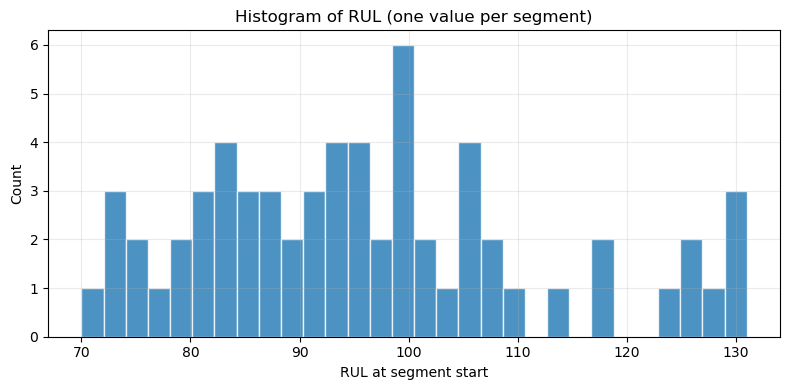

In [11]:
# Histogram of one RUL value per segment (RUL at segment start)
rul_per_segment = (
    df.sort_values(["segment_id", "time"])
      .groupby("segment_id", as_index=False)["rul"]
      .first()["rul"]
      .to_numpy(dtype=float)
)

rul_per_segment = rul_per_segment[np.isfinite(rul_per_segment)]

plt.figure(figsize=(8, 4))
plt.hist(rul_per_segment, bins=30, color="tab:blue", alpha=0.8, edgecolor="white")
plt.title("Histogram of RUL (one value per segment)")
plt.xlabel("RUL at segment start")
plt.ylabel("Count")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [12]:
np.min(rul_per_segment), np.max(rul_per_segment)

(np.float64(70.0), np.float64(131.0))

## Region-Specific Exponential Degradation Model
This model uses two parameters and shares the same functional form for latent degradation:
- $L(t)=\frac{a_0}{a_1}\left(\exp(a_1t)-1\right)$
- $L_{obs} \sim \mathcal{N}(L(t), \sigma_{obs})$
Implementation notes:
- A near-zero $a_1$ safeguard uses the limit $L(t) \approx a_0 t$.

In [13]:
# Latent degradation model with segment-level coefficients:
# L(t) = (a0 / a1) * (exp(a1 * t) - 1)
model_df = df[["machine_id", "segment_id", "time_reset", "region", "degra_level_observed", "brake_temperature", "vibration_level"]].copy()
model_df = model_df.dropna(subset=["segment_id", "time_reset", "region", "degra_level_observed", "brake_temperature", "vibration_level"]).reset_index(drop=True)

regions = np.sort(model_df["region"].unique())
segments = np.sort(model_df["segment_id"].unique())

region_to_idx = {r: i for i, r in enumerate(regions)}
segment_to_idx = {s: i for i, s in enumerate(segments)}

segment_idx = model_df["segment_id"].map(segment_to_idx).to_numpy(dtype=int)
segment_region = (
    model_df.groupby("segment_id", sort=True)["region"]
    .first()
    .reindex(segments)
    .to_numpy()
)
segment_region_idx = np.array([region_to_idx[r] for r in segment_region], dtype=int)
time_obs = model_df["time_reset"].to_numpy(dtype=float)
Lobs = model_df["degra_level_observed"].to_numpy(dtype=float)

coords = {
    "region": regions,
    "segment": segments,
    "obs_id": np.arange(len(model_df)),
}

with pm.Model(coords=coords) as exp_model:
    segment_idx_data = pm.Data("segment_idx", segment_idx, dims="obs_id")
    time_data = pm.Data("time_data", time_obs, dims="obs_id")
    Lobs_data = pm.Data("Lobs_data", Lobs, dims="obs_id")

    a0_obs = pm.HalfNormal("a0_obs", sigma=0.01, dims="segment")
    a1_obs = pm.HalfNormal("a1_obs", sigma=0.01, dims="segment")

    # Stable form around a1=0: limit is a0 * t.
    eps = 1e-6
    a0_segment = a0_obs[segment_idx_data]
    a1_segment = a1_obs[segment_idx_data]
    L_latent = pm.Deterministic(
        "L_latent",
        pt.where(
            pt.abs(a1_segment) < eps,
            a0_segment * time_data,
            (a0_segment / a1_segment) * (pt.exp(a1_segment * time_data) - 1.0),
        ),
        dims="obs_id",
    )

    sigma_obs = pm.HalfNormal("sigma_obs", sigma=5.0)
    pm.Normal("Lobs", mu=L_latent, sigma=sigma_obs, observed=Lobs_data, dims="obs_id")

exp_model

   a0_obs ~ HalfNormal(0, 0.01)
   a1_obs ~ HalfNormal(0, 0.01)
sigma_obs ~ HalfNormal(0, 5)
 L_latent ~ Deterministic(f(a0_obs, a1_obs))
     Lobs ~ Normal(L_latent, sigma_obs)

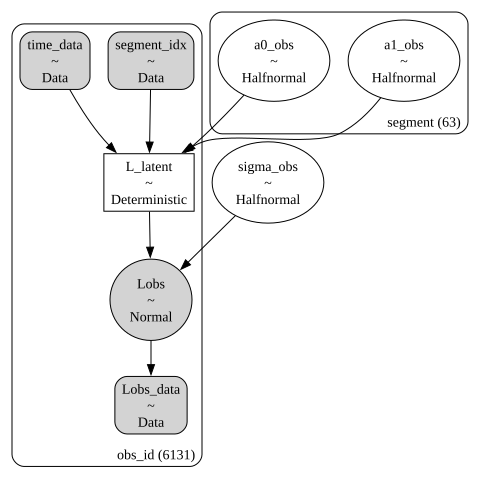

In [14]:
pm.model_to_graphviz(exp_model)

In [45]:
# second model with temp and vib as additional observed variables
temp_obs = model_df["brake_temperature"].to_numpy(dtype=float)
vib_obs = model_df["vibration_level"].to_numpy(dtype=float)

with pm.Model(coords=coords) as exp_model2:
    segment_idx_data = pm.Data("segment_idx", segment_idx, dims="obs_id")
    # Lobs_data = pm.Data("Lobs_data", Lobs, dims="obs_id")
    time_data = pm.Data("time_data", time_obs, dims="obs_id")
    temp_data = pm.Data("temp_data", temp_obs, dims="obs_id")
    vib_data = pm.Data("vib_data", vib_obs, dims="obs_id")

    a0_obs = pm.HalfNormal("a0_obs", sigma=0.01, dims="segment")
    a1_obs = pm.HalfNormal("a1_obs", sigma=0.01, dims="segment")
    a_temp = pm.HalfNormal("a_temp", sigma=10.0)
    b_temp = pm.HalfNormal("b_temp", sigma=1.0)
    a_vib = pm.HalfNormal("a_vib", sigma=1.0)
    b_vib = pm.HalfNormal("b_vib", sigma=1.0)
    # a_temp = 40.0
    # b_temp = 1.5
    # a_vib = 2.5
    # b_vib = 2.0
    sigma_temp = pm.HalfNormal("sigma_temp", sigma=5.0)
    sigma_vib = pm.HalfNormal("sigma_vib", sigma=5.0)

    # Stable form around a1=0: limit is a0 * t.
    eps = 1e-6
    a0_segment = a0_obs[segment_idx_data]
    a1_segment = a1_obs[segment_idx_data]
    L_latent = pm.Deterministic(
        "L_latent",
        pt.where(
            pt.abs(a1_segment) < eps,
            a0_segment * time_data,
            (a0_segment / a1_segment) * (pt.exp(a1_segment * time_data) - 1.0),
        ),
        dims="obs_id",
    )

    pm.Normal("temp_obs", mu=pm.math.clip(a_temp * (L_latent/10.0)**b_temp, 0, np.inf), sigma=sigma_temp, observed=temp_data, dims="obs_id")
    pm.Normal("vib_obs", mu=pm.math.clip(a_vib * (L_latent/10.0)**b_vib, 0, np.inf), sigma=sigma_vib, observed=vib_data, dims="obs_id")
    # sigma_obs = pm.HalfNormal("sigma_obs", sigma=5.0)
    # pm.Normal("Lobs", mu=L_latent, sigma=sigma_obs, observed=Lobs_data, dims="obs_id")

exp_model2

    a0_obs ~ HalfNormal(0, 0.01)
    a1_obs ~ HalfNormal(0, 0.01)
    a_temp ~ HalfNormal(0, 10)
    b_temp ~ HalfNormal(0, 1)
     a_vib ~ HalfNormal(0, 1)
     b_vib ~ HalfNormal(0, 1)
sigma_temp ~ HalfNormal(0, 5)
 sigma_vib ~ HalfNormal(0, 5)
  L_latent ~ Deterministic(f(a0_obs, a1_obs))
  temp_obs ~ Normal(f(a_temp, b_temp, a0_obs, a1_obs), sigma_temp)
   vib_obs ~ Normal(f(a_vib, b_vib, a0_obs, a1_obs), sigma_vib)

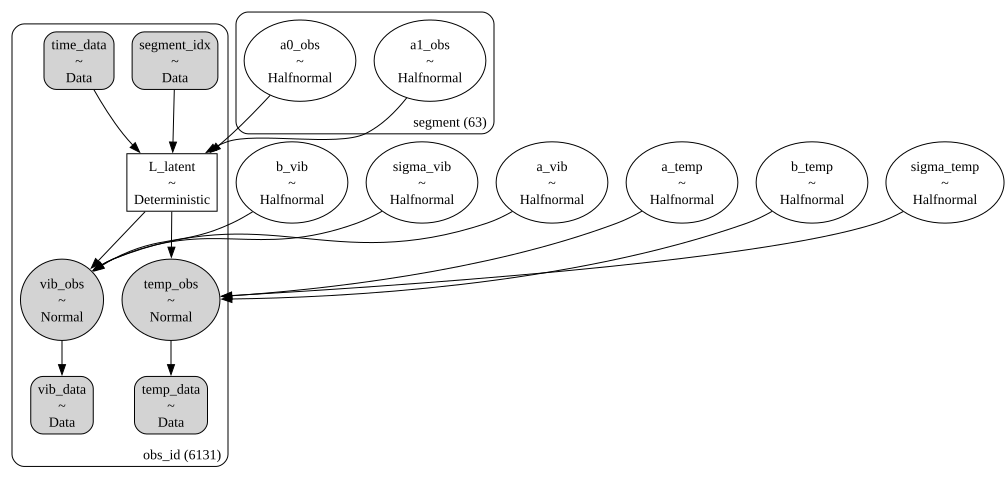

In [46]:
pm.model_to_graphviz(exp_model2)

In [17]:
with exp_model:
    idata_exp = pm.sample(target_accept=0.9)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a0_obs, a1_obs, sigma_obs]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 635 seconds.


In [18]:
# # Per-region subplots for a0_obs and a1_obs posteriors
# n_regions = len(regions)
# fig, axes = plt.subplots(n_regions, 2, figsize=(14, 4 * n_regions))

# for i, region_value in enumerate(regions):
#     segs_in_region = [s for s, r in zip(segments, segment_region) if r == region_value]
#     seg_indices = [list(segments).index(s) for s in segs_in_region]

#     for param, col in [("a0_obs", 0), ("a1_obs", 1)]:
#         ax = axes[i, col]
#         samples = idata_exp.posterior[param].values[:, :, seg_indices]
#         samples_flat = samples.reshape(-1, len(seg_indices))
#         for j, seg in enumerate(segs_in_region):
#             ax.hist(samples_flat[:, j], bins=40, alpha=0.4, label=f"seg {seg}", density=True)
#         ax.set_title(f"Region {region_value} — {param}")
#         ax.set_xlabel(param)
#         ax.legend(fontsize=7, ncol=2)
#         ax.grid(alpha=0.3)

# if __name__ == "__main__":
#     pass  # placeholder to avoid syntax issues

# fig.tight_layout()
# plt.show()

# # sigma_obs posterior

# # Posterior plots for a_temp, b_temp, a_vib, b_vib
# fig_params, axes_params = plt.subplots(2, 2, figsize=(12, 8))

# # param_names = ["a_temp", "b_temp", "a_vib", "b_vib"]
# # for idx, param_name in enumerate(param_names):
# #     ax = axes_params.flat[idx]
# #     samples = idata_exp.posterior[param_name].values.ravel()
# #     ax.hist(samples, bins=40, density=True, color="tab:green", alpha=0.7, edgecolor="black")
# #     ax.set_title(f"{param_name} posterior")
# #     ax.set_xlabel(param_name)
# #     ax.grid(alpha=0.3)

# posterior_param_names = ["sigma_temp", "sigma_vib"]
# posterior_colors = ["tab:green", "tab:orange"]

# for idx, param_name in enumerate(posterior_param_names):
#     ax = axes_params.flat[idx]
#     samples = idata_exp.posterior[param_name].values.ravel()
#     ax.hist(
#         samples,
#         bins=40,
#         density=True,
#         color=posterior_colors[idx],
#         alpha=0.7,
#         edgecolor="black",
#     )
#     ax.set_title(f"{param_name} posterior")
#     ax.set_xlabel(param_name)
#     ax.grid(alpha=0.3)

# for ax in axes_params.flat[len(posterior_param_names):]:
#     ax.set_visible(False)

# fig_params.tight_layout()
# plt.show()
# fig_sigma, ax_sigma = plt.subplots(1, 1, figsize=(6, 4))
# sigma_samples = idata_exp.posterior["sigma_obs"].values.ravel()
# ax_sigma.hist(sigma_samples, bins=40, density=True, color="tab:purple", alpha=0.7)
# ax_sigma.set_title("sigma_obs posterior")
# ax_sigma.set_xlabel("sigma_obs")
# ax_sigma.grid(alpha=0.3)
# fig_sigma.tight_layout()
# plt.show()

# plt.tight_layout()
# plt.show()

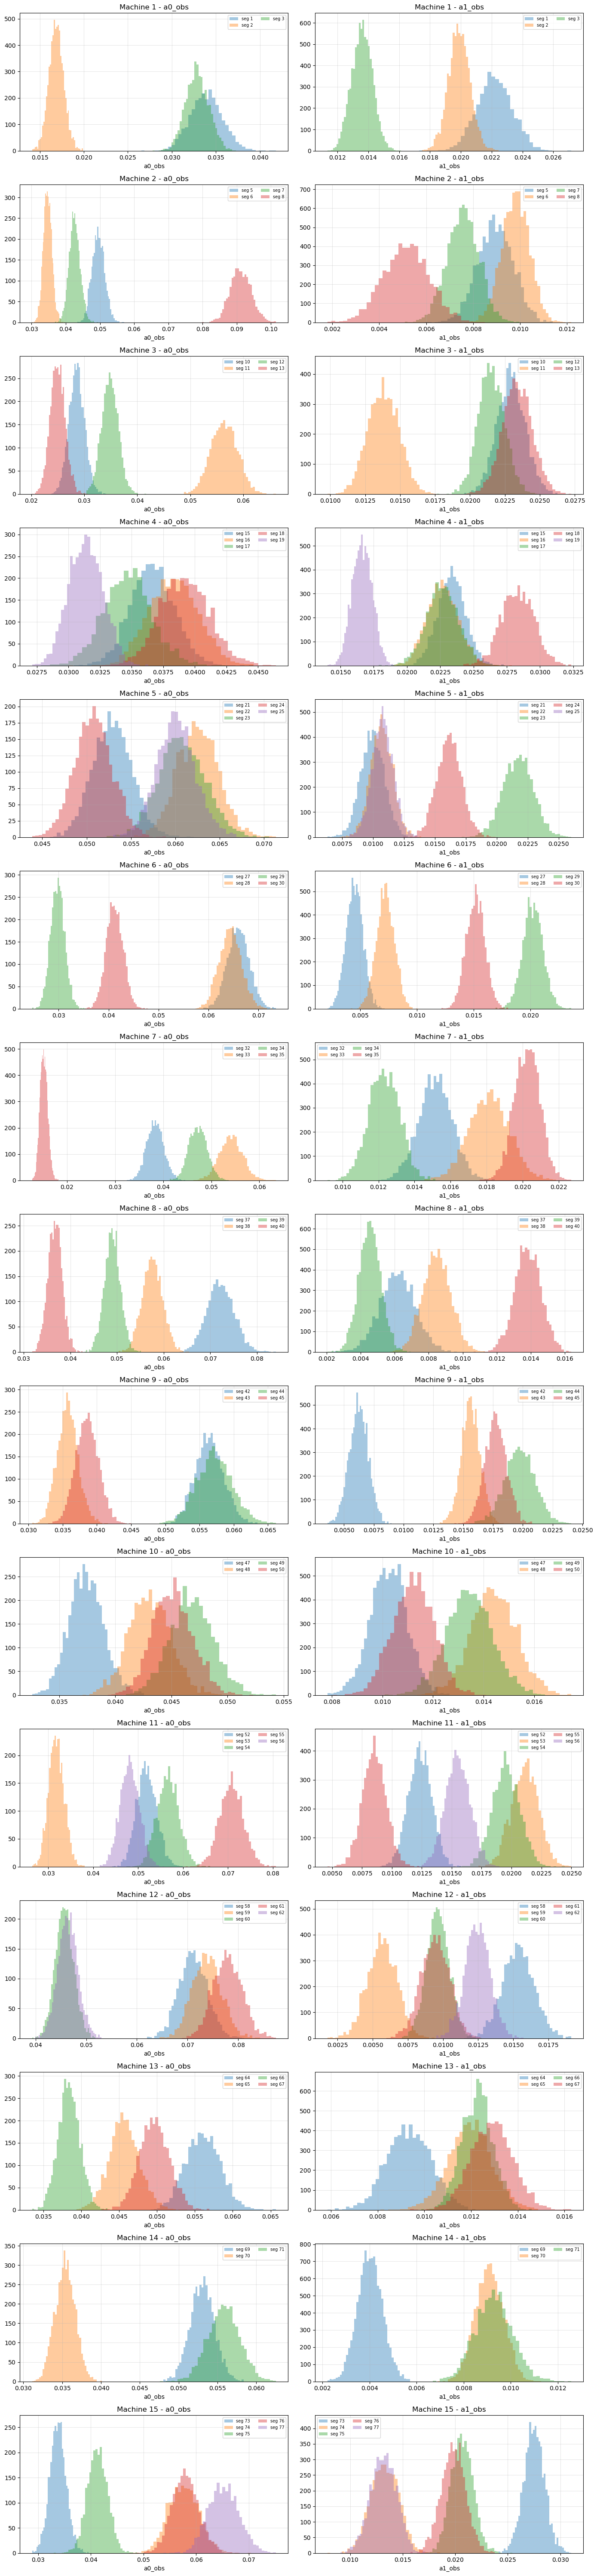

In [19]:
# Per-machine subplots for a0_obs and a1_obs posteriors
machines = np.sort(model_df["machine_id"].unique())
segment_machine = (
    model_df.groupby("segment_id", sort=True)["machine_id"]
    .first()
    .reindex(segments)
    .to_numpy()
)

n_machines = len(machines)
fig, axes = plt.subplots(n_machines, 2, figsize=(14, 4 * n_machines), squeeze=False)

for i, machine_value in enumerate(machines):
    segs_in_machine = [s for s, m in zip(segments, segment_machine) if m == machine_value]
    seg_indices = [segment_to_idx[s] for s in segs_in_machine]

    for param, col in [("a0_obs", 0), ("a1_obs", 1)]:
        ax = axes[i, col]
        samples = idata_exp.posterior[param].values[:, :, seg_indices]
        samples_flat = samples.reshape(-1, len(seg_indices))
        for j, seg in enumerate(segs_in_machine):
            ax.hist(samples_flat[:, j], bins=40, alpha=0.4, label=f"seg {seg}", density=True)
        ax.set_title(f"Machine {machine_value} - {param}")
        ax.set_xlabel(param)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [20]:
a0_samples = idata_exp.posterior["a0_obs"].values.flatten()
a1_samples = idata_exp.posterior["a1_obs"].values.flatten()
min_a0, max_a0 = np.min(a0_samples), np.max(a0_samples)
min_a1, max_a1 = np.min(a1_samples), np.max(a1_samples)

mean_a01 = np.mean([a0_samples, a1_samples], axis=1)
cov_matrix = np.cov(a0_samples, a1_samples)
print(f"Mean of a0_obs and a1_obs samples: {mean_a01}")
print(f"Covariance matrix:\n{cov_matrix}")

sigma_obs_samples = idata_exp.posterior["sigma_obs"].values.flatten()
sigma_obs_mean = np.mean(sigma_obs_samples)
sigma_obs_std = np.std(sigma_obs_samples)
print(f"Mean of sigma_obs samples: {sigma_obs_mean:.6f}")
print(f"Standard deviation of sigma_obs samples: {sigma_obs_std:.6f}")

Mean of a0_obs and a1_obs samples: [0.04778364 0.0142768 ]
Covariance matrix:
[[ 2.19554695e-04 -5.21427661e-05]
 [-5.21427661e-05  3.66817272e-05]]
Mean of sigma_obs samples: 0.417007
Standard deviation of sigma_obs samples: 0.003818


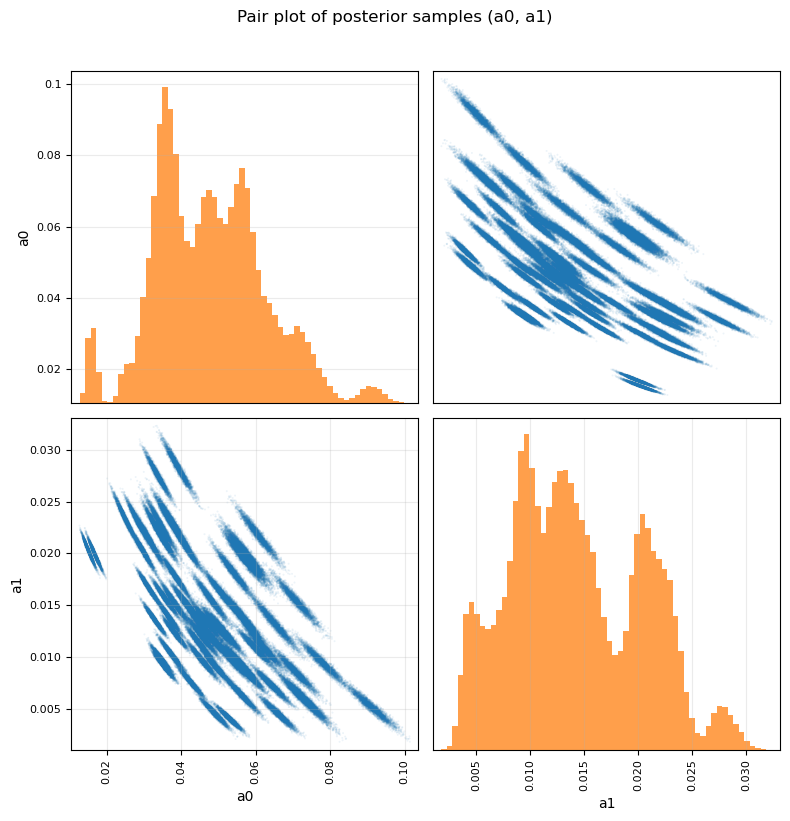

In [21]:
# Plot all posterior samples of a0 and a1
post_a0 = idata_exp.posterior["a0_obs"].values.reshape(-1)
post_a1 = idata_exp.posterior["a1_obs"].values.reshape(-1)

# Pair plot of all a0/a1 samples (2x2 matrix)
samples_df = pd.DataFrame({"a0": post_a0, "a1": post_a1})
axes_pair = pd.plotting.scatter_matrix(
    samples_df,
    figsize=(8, 8),
    diagonal="hist",
    alpha=0.08,
    s=8,
    color="tab:blue",
    hist_kwds={"bins": 60, "density": True, "alpha": 0.75, "color": "tab:orange"},
)

for row in axes_pair:
    for ax in row:
        ax.grid(alpha=0.25)

plt.suptitle("Pair plot of posterior samples (a0, a1)", y=1.02)
plt.tight_layout()
plt.show()

## Prediction Model — Online Inference with RUL Estimation

For a **new observed segment** $(t_i,\, L_{\mathrm{obs},i})$ from a machine of known region $r$, this model:

1. **Fits** $(a_0, a_1)$ to the history of the segment using a prior for both parameters.
2. **Reconstructs** the latent degradation $L(t)$ over the observed window (past & present).
3. **Extrapolates** $L(t)$ beyond the last observation (future forecast).
4. Computes the **Remaining Useful Life (RUL)** as the time until $L$ first surpasses the critical level $L_c = 10$:

$$
t^* = \frac{\ln\!\left(1 + L_c\,\dfrac{a_1}{a_0}\right)}{a_1}, \qquad
\mathrm{RUL} = \max\!\left(t^* - t_{\mathrm{last}},\; 0\right)
$$

The full posterior over $(a_0, a_1)$ propagates through the closed-form expression for $t^*$, yielding a **posterior distribution of RUL** that captures both parameter uncertainty and observation noise.

In [ ]:
# Prediction model: fit (a0, a1) for a new segment using training posteriors as priors
def return_RUL_prediction():
    with pm.Model() as RUL_prediction:
        time_data = pm.Data("time", np.zeros(50))
        observed_degradation_data = pm.Data("observed_degradation_data", np.zeros(50))
        time_data_predict = pm.Data("time_predict", np.zeros(100))

        a01 = pm.MvNormal("parameters", mu=mean_a01, cov=cov_matrix, shape=2)
        a0 = pm.math.clip(a01[0], min_a0, max_a0)
        a1 = pm.math.clip(a01[1], min_a1, max_a1)
        sigma_obs = pm.TruncatedNormal("sigma_obs", mu=sigma_obs_mean, sigma=sigma_obs_std, lower=0.0)
        sigma_RUL = pm.HalfNormal("sigma_RUL", sigma=5.0)

        eps = 1e-6
        mu_degradation = pm.Deterministic(
            "mu_degradation",
            pt.where(
                pt.abs(a1) < eps,
                a0 * time_data_predict,
                (a0 / a1) * (pt.exp(a1 * time_data_predict) - 1.0),
            ),
        )

        pm.Normal("observed_degradation", mu=mu_degradation[:observed_degradation_data.shape[0]], sigma=sigma_obs, observed=observed_degradation_data)
        pm.Normal("predicted_degradation", mu=mu_degradation, sigma=sigma_obs)

        L_c = 10.0
        t_critical = pt.where(
            pt.abs(a1) < eps,
            L_c / pt.maximum(a0, eps),
            pt.log(pt.maximum(1.0 + L_c * (a1 / pt.maximum(a0, eps)), eps)) / a1,
        )

        pm.Deterministic("RUL", pt.maximum(t_critical - time_data[-1], 0.0))
    return RUL_prediction

RUL_prediction = return_RUL_prediction()
RUL_prediction

           parameters ~ MultivariateNormal(f(), <constant>)
            sigma_obs ~ TruncatedNormal(0.417, 0.00382, 0, inf)
predicted_degradation ~ Normal(mu_degradation, sigma_obs)
       mu_degradation ~ Deterministic(f(parameters))
                  RUL ~ Deterministic(f(parameters))
 observed_degradation ~ Normal(f(parameters), sigma_obs)

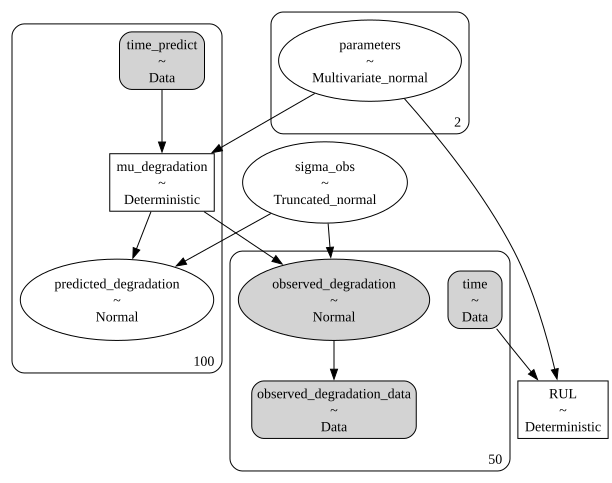

In [23]:
pm.model_to_graphviz(RUL_prediction)

In [24]:
# import logging 
# logger = logging.getLogger("pymc")
# logger.setLevel(logging.CRITICAL) # suppresses all unnecessary written output

In [25]:
test_folder = train_folder.parent / "test"

test_dataframes = {
    csv_file.stem: pd.read_csv(csv_file)
    for csv_file in test_folder.glob("*.csv")
}

list(test_dataframes.keys())

['complete_df_test']

In [26]:
# Get test dataframe from the loaded dictionary
test_df = test_dataframes.get("complete_df_test")

# Fallback: use the first available test dataframe if key is different
if test_df is None:
    test_df = next(iter(test_dataframes.values()))

test_df.head()

,machine_id,time,degra_level_observed,region,route,speed,load,brake_temperature,vibration_level,rul,segment_id
0,16,0,0.000000,0,1,37.789484,0.759920,0.000000,0.000000,97,1
1,16,1,0.207097,0,1,31.829398,0.508003,0.601623,0.006665,96,1
2,16,2,0.134757,0,1,31.600209,0.704945,0.000000,0.133962,95,1
3,16,3,0.000000,0,0,94.206996,0.678038,0.000000,0.000000,94,1
4,16,4,0.000000,0,1,24.540111,0.659462,0.000000,0.000000,93,1


In [ ]:
# Extract first segment from test_df
first_seg_id = test_df["segment_id"].iloc[0]
from_time = 50.0
seg_df = test_df.loc[test_df["segment_id"] == first_seg_id].sort_values("time").reset_index(drop=True)

# Build reset time (segment-relative)
t_min = seg_df["time"].min()
time_seg = (seg_df["time"] - t_min).to_numpy(dtype=float).flatten()
obs_seg = seg_df["degra_level_observed"].to_numpy(dtype=float).flatten()
temp_seg = seg_df["brake_temperature"].to_numpy(dtype=float).flatten()
vib_seg = seg_df["vibration_level"].to_numpy(dtype=float).flatten()
time_seg_cut = time_seg[time_seg <= from_time]
obs_seg_cut = obs_seg[:len(time_seg_cut)]
temp_seg_cut = temp_seg[:len(time_seg_cut)]
vib_seg_cut = vib_seg[:len(time_seg_cut)]

# Sample posterior and posterior predictive
RUL_prediction = return_RUL_prediction()  # create a new model instance to avoid shared state issues
with RUL_prediction:
    pm.set_data({"time": time_seg_cut, "observed_degradation_data": obs_seg_cut, "time_predict": time_seg})
    idata_seg = pm.sample(target_accept=0.9)
    # idata_post = pm.sample_posterior_predictive(idata_seg)#, progressbar=False)

# Latent degradation quantiles (mu_degradation)
mu_samples = idata_seg.posterior["mu_degradation"].values.reshape(-1, len(time_seg))
mu_q05 = np.quantile(mu_samples, 0.05, axis=0)
mu_q95 = np.quantile(mu_samples, 0.95, axis=0)

# Predicted degradation quantiles (posterior predictive)
pred_pp = idata_seg.posterior["predicted_degradation"].values.reshape(-1, len(time_seg))
pred_q05 = np.quantile(pred_pp, 0.05, axis=0)
pred_q95 = np.quantile(pred_pp, 0.95, axis=0)


Initializing NUTS using jitter+adapt_diag...
c:\Users\erik.hostens\AppData\Local\miniforge3\envs\Flambay\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [parameters, sigma_obs, predicted_degradation]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 147 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


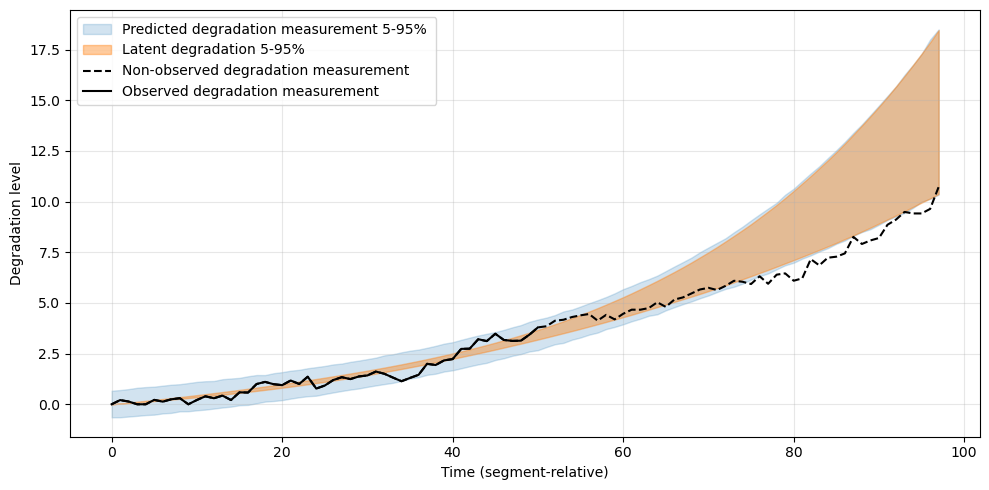

In [28]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(time_seg, pred_q05, pred_q95, alpha=0.2, color="tab:blue", label="Predicted degradation measurement 5-95% ")
ax.fill_between(time_seg, mu_q05, mu_q95, alpha=0.4, color="tab:orange", label="Latent degradation 5-95%")
ax.plot(time_seg, obs_seg, color="black", linestyle='--', label="Non-observed degradation measurement")
ax.plot(time_seg_cut, obs_seg_cut, color="black", label="Observed degradation measurement")
ax.set_xlabel("Time (segment-relative)")
ax.set_ylabel("Degradation level")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
# adjust logp of posterior sample to perform non-uniform resampling based
def RUL_prediction_resample(t, L, t_predict):
    # np.random.seed(42)
    # a01 = np.random.multivariate_normal(mean_a01, cov_matrix, size=10000)
    # a0 = a01[:, 0]
    # a1 = a01[:, 1] #np.clip(a01[:, 1], min_a1, max_a1)
    a0 = np.random.uniform(min_a0, max_a0, size=10000)
    a1 = np.random.uniform(min_a1, max_a1, size=10000)
    t_crit = np.log(1.0 + 10.0 * (a1 / a0)) / a1
    mask_valid = (t_crit > 65) & (t_crit < 135)
    a0 = a0[mask_valid]
    a1 = a1[mask_valid]
    t_crit = t_crit[mask_valid]

    Lpred = (a0[None, :] / a1[None, :]) * (np.exp(a1[None, :] * t[:, None]) - 1.0)
    
    RUL_sample = np.maximum(t_crit - t[-1], 0.0)
    Lerr = Lpred - L[:, None]
    logp_corr = np.sum(-Lerr**2, axis=0).flatten()

    # Stabilize weights to avoid numerical underflow/overflow
    logp_corr = logp_corr - np.max(logp_corr)
    w = np.exp(logp_corr)
    w = w / np.sum(w)

    index_resampled = np.random.choice(len(a0), size=1000, p=w)
    Lpred_full = (a0[None, index_resampled] / a1[None, index_resampled]) * (
        np.exp(a1[None, index_resampled] * t_predict[:, None]) - 1.0
    )

    RUL_pred = RUL_sample[index_resampled]
    return Lpred_full, RUL_pred

In [47]:
sigma_obs_mean

np.float64(0.41700663615377015)

In [ ]:
# adjust logp of posterior sample to perform non-uniform resampling based

sigma_obs_mean = 0.42 #np.mean(idata_exp.posterior["sigma_obs"].values.flatten())
sigma_temp_mean = 4.5 #np.mean(idata_exp.posterior["sigma_temp"].values.flatten())
sigma_vib_mean = 0.2575 #np.mean(idata_exp.posterior["sigma_vib"].values.flatten
sigma_L_crit = 1.0

def RUL_prediction_resample2(t, L, vib, temp, t_predict):
    # np.random.seed(42)
    # a01 = np.random.multivariate_normal(mean_a01, cov_matrix, size=10000)
    # a0 = a01[:, 0]
    # a1 = a01[:, 1] #np.clip(a01[:, 1], min_a1, max_a1)
    L_crit = 10.0 + sigma_L_crit * np.random.randn(10000)
    a0 = np.random.uniform(min_a0, max_a0, size=10000)
    a1 = np.random.uniform(min_a1, max_a1, size=10000)
    t_crit = np.log(1.0 + L_crit * (a1 / a0)) / a1
    mask_valid = (t_crit > 65) & (t_crit < 135)
    a0 = a0[mask_valid]
    a1 = a1[mask_valid]
    t_crit = t_crit[mask_valid]

    Lpred = (a0[None, :] / a1[None, :]) * (np.exp(a1[None, :] * t[:, None]) - 1.0)
    temp_pred = 40.0 * (Lpred/10.0)**1.5
    vib_pred = 2.5 * (Lpred/10.0)**2.
    
    RUL_sample = np.maximum(t_crit - t[-1], 0.0)
    Lerr = Lpred - L[:, None]
    temp_err = temp_pred - temp[:, None]
    vib_err = vib_pred - vib[:, None]
    logp_corr = np.zeros(len(a0))
    # logp_corr += np.sum(-np.log(sigma_obs_mean) - (Lerr / sigma_obs_mean)**2 / 2, axis=0).flatten()
    logp_corr += np.sum(-np.log(sigma_temp_mean) - (temp_err / sigma_temp_mean)**2 / 2, axis=0).flatten()
    logp_corr += np.sum(-np.log(sigma_vib_mean) - (vib_err / sigma_vib_mean)**2 / 2, axis=0).flatten()

    # Stabilize weights to avoid numerical underflow/overflow
    logp_corr = logp_corr - np.max(logp_corr)
    w = np.exp(logp_corr)
    w = w / np.sum(w)

    index_resampled = np.random.choice(len(a0), size=1000, p=w)
    Lpred_full = (a0[None, index_resampled] / a1[None, index_resampled]) * (
        np.exp(a1[None, index_resampled] * t_predict[:, None]) - 1.0
    )

    RUL_pred = RUL_sample[index_resampled]
    return Lpred_full, RUL_pred

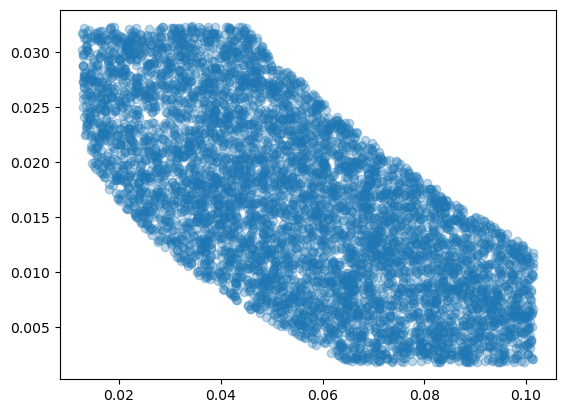

In [31]:
a0 = np.random.uniform(min_a0, max_a0, size=10000)
a1 = np.random.uniform(min_a1, max_a1, size=10000)
t_crit = np.log(1.0 + 10.0 * (a1 / a0)) / a1
mask_valid = (t_crit > 65) & (t_crit < 135)
np.sum(mask_valid)
plt.scatter(a0[mask_valid], a1[mask_valid], alpha=0.3, label="Valid samples")

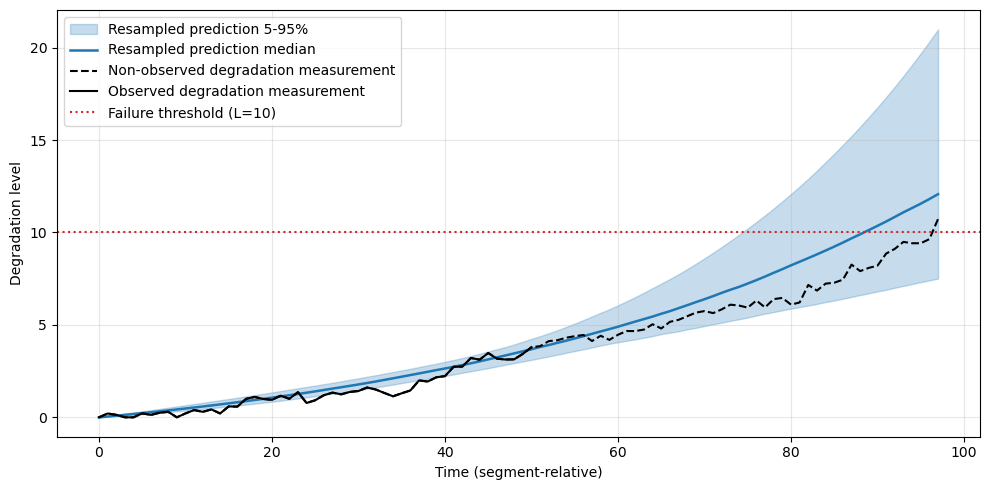

In [32]:
# Resampling-based prediction (no PyMC)
# Lpred_full, RUL_pred = RUL_prediction_resample(t=time_seg_cut, L=obs_seg_cut, t_predict=time_seg)
Lpred_full, RUL_pred = RUL_prediction_resample2(t=time_seg_cut, L=obs_seg_cut, vib=vib_seg_cut, temp=temp_seg_cut, t_predict=time_seg)
pred_q05 = np.quantile(Lpred_full, 0.05, axis=1)
pred_q95 = np.quantile(Lpred_full, 0.95, axis=1)
pred_q50 = np.quantile(Lpred_full, 0.5, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    time_seg,
    pred_q05,
    pred_q95,
    alpha=0.25,
    color="tab:blue",
    label="Resampled prediction 5-95%",
)
ax.plot(time_seg, pred_q50, color="tab:blue", linewidth=1.8, label="Resampled prediction median")
ax.plot(time_seg, obs_seg, color="black", linestyle="--", label="Non-observed degradation measurement")
ax.plot(time_seg_cut, obs_seg_cut, color="black", label="Observed degradation measurement")
ax.axhline(10.0, color="tab:red", linestyle=":", linewidth=1.5, label="Failure threshold (L=10)")
ax.set_xlabel("Time (segment-relative)")
ax.set_ylabel("Degradation level")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

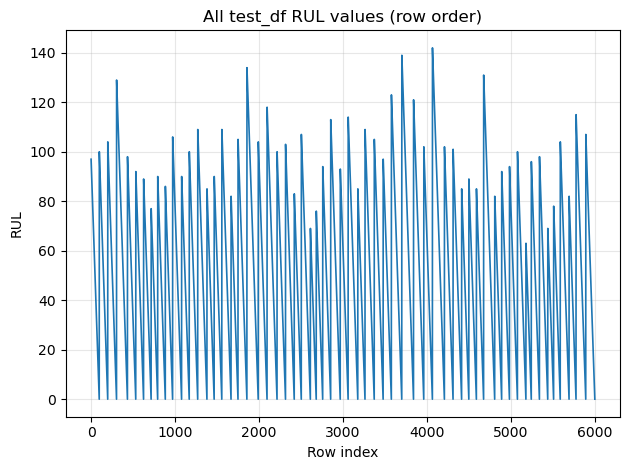

In [33]:
# Plot all RUL values from test_df
rul_all = test_df["rul"].to_numpy(dtype=float)
rul_all = rul_all[np.isfinite(rul_all)]

# RUL in dataframe order
plt.plot(rul_all, color="tab:blue", linewidth=1.2)
plt.title("All test_df RUL values (row order)")
plt.xlabel("Row index")
plt.ylabel("RUL")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Online Evaluation Variant
The next cell runs rolling online RUL inference from empty history to full history and compares the predicted RUL 5-95% interval against ground-truth RUL.


Segment index: 1
Ground truth RUL at start: 97.0


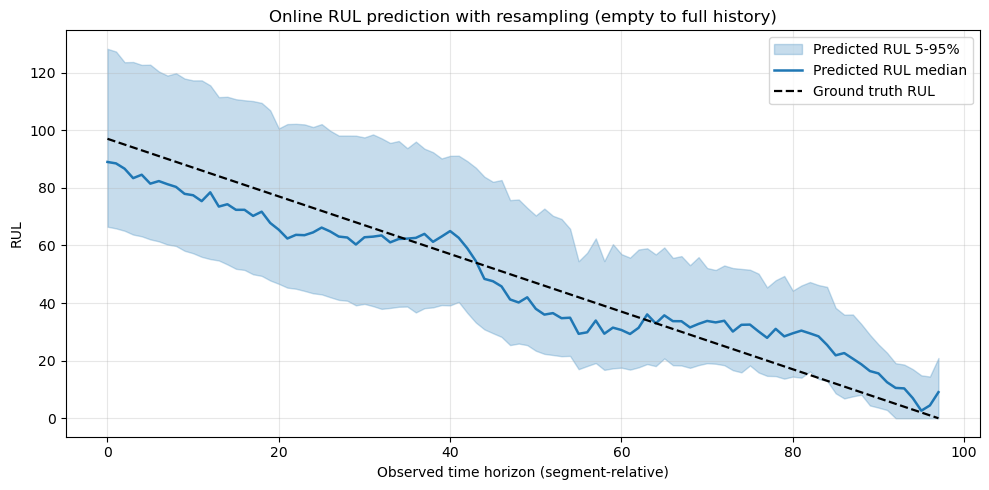


Segment index: 4
Ground truth RUL at start: 129.0


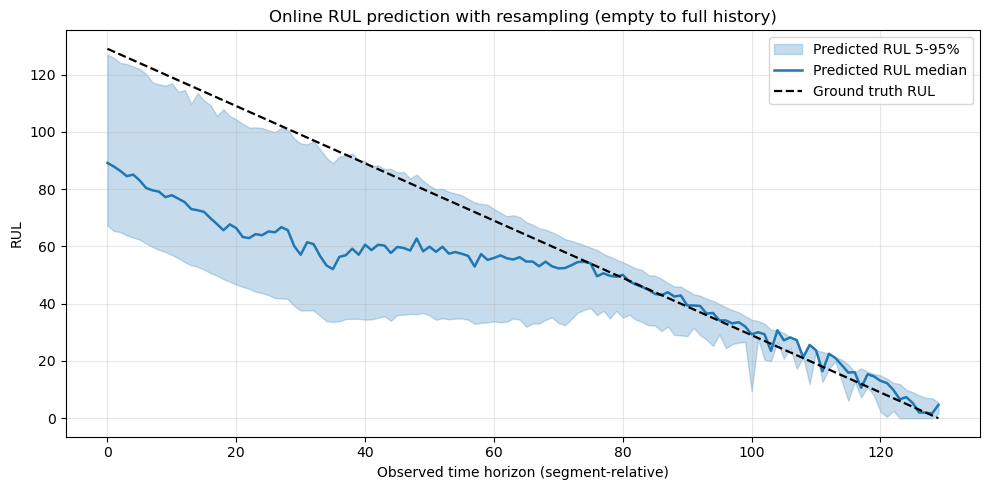


Segment index: 8
Ground truth RUL at start: 89.0


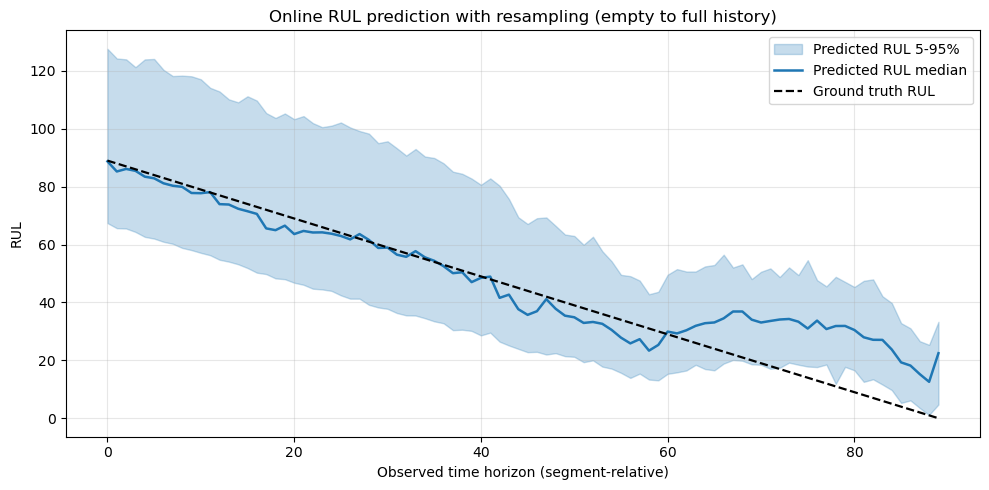


Segment index: 11
Ground truth RUL at start: 90.0


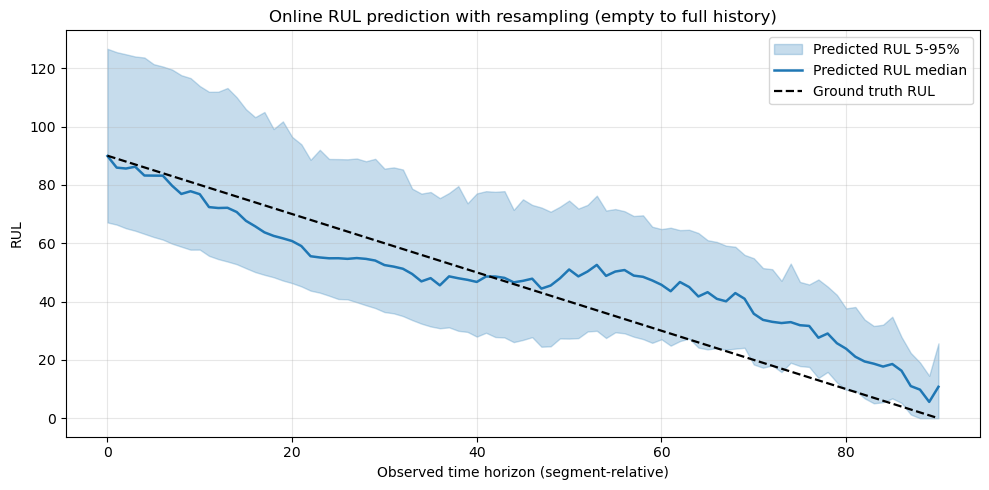


Segment index: 17
Ground truth RUL at start: 109.0


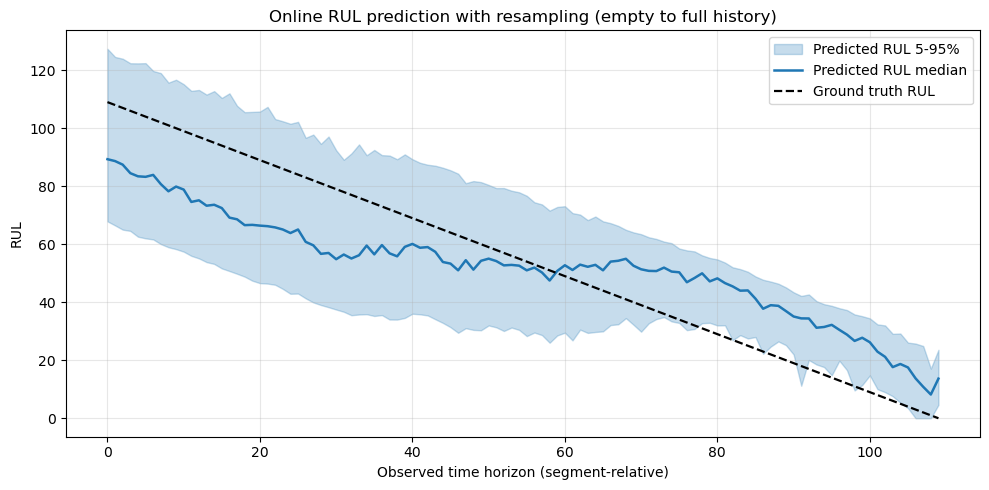

In [43]:
for seg_id in [1,4,8,11,17]:  # loop over a few segments in test_df
    # Extract segment from test_df
    print(f"\nSegment index: {seg_id}")
    seg_df = test_df.loc[test_df["segment_id"] == seg_id].sort_values("time").reset_index(drop=True)
    t_min = seg_df["time"].min()
    time_seg = (seg_df["time"] - t_min).to_numpy(dtype=float).flatten()
    obs_seg = seg_df["degra_level_observed"].to_numpy(dtype=float).flatten()
    temp_seg = seg_df["brake_temperature"].to_numpy(dtype=float).flatten()
    vib_seg = seg_df["vibration_level"].to_numpy(dtype=float).flatten()
    gt_rul = seg_df["rul"].to_numpy(dtype=float).flatten()
    print(f"Ground truth RUL at start: {gt_rul[0]}")

    # Online RUL inference: grow observed window from empty to full time_seg
    n_steps = len(time_seg)

    rul_q05 = np.full(n_steps, np.nan)
    rul_q50 = np.full(n_steps, np.nan)
    rul_q95 = np.full(n_steps, np.nan)

    for k in range(n_steps):
        t_obs_k = time_seg[:k+1]
        L_obs_k = obs_seg[:k+1]
        temp_obs_k = temp_seg[:k+1]
        vib_obs_k = vib_seg[:k+1]

        # _, RUL_sample_k = RUL_prediction_resample(
        #     t=t_obs_k,
        #     L=L_obs_k,
        #     t_predict=time_seg,
        # )
        _, RUL_sample_k = RUL_prediction_resample2(
            t=t_obs_k,
            L=L_obs_k,
            temp=temp_obs_k,
            vib=vib_obs_k,
            t_predict=time_seg,
        )

        valid_k = np.isfinite(RUL_sample_k) & (RUL_sample_k >= 0.0)
        if np.any(valid_k):
            rul_q05[k] = np.quantile(RUL_sample_k[valid_k], 0.05)
            rul_q50[k] = np.quantile(RUL_sample_k[valid_k], 0.50)
            rul_q95[k] = np.quantile(RUL_sample_k[valid_k], 0.95)

    # Plot RUL uncertainty band and median vs ground truth
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(time_seg, rul_q05, rul_q95, alpha=0.25, color="tab:blue", label="Predicted RUL 5-95%")
    ax.plot(time_seg, rul_q50, color="tab:blue", linewidth=1.8, label="Predicted RUL median")
    ax.plot(time_seg, gt_rul, color="black", linestyle="--", linewidth=1.6, label="Ground truth RUL")
    ax.set_xlabel("Observed time horizon (segment-relative)")
    ax.set_ylabel("RUL")
    ax.set_title("Online RUL prediction with resampling (empty to full history)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()